In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from copy import deepcopy
from build_solver import build_erg_time_opt_solver, build_erg_time_opt_solver_print
import pickle


In [33]:
def get_sol_from_init(x, args, step_size=1e-3, c=1.0, max_iter=20000):
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(deepcopy(init_sol), args, step_size=1e-3, c=c)
    solver.solve(args=args, max_iter=max_iter, eps=1e-18)
    sol = solver.get_solution()
    return init_sol, sol

def print_erg(x, u, tf, args, step_size=1e-3, c=1.0, max_iter=1):
    init_sol = {'x': x, 'u' : u, 'tf': tf}
    solver = build_erg_time_opt_solver_print(deepcopy(init_sol), args, step_size=1e-3, c=c)
    solver.solve(args=args, max_iter=max_iter, eps=1e-18)
    return None

def plot_traj(_axs, sol):
    init_sol, final_sol = sol

    # _axs[1].set_title('t_f = {:4.2f}'.format(final_sol['tf']))
    _axs[1].set_title('N = {:4.2f}'.format(len(final_sol['x'])))
    _axs[1].plot(final_sol['x'][:,0], final_sol['x'][:,1],'g.')
    _axs[1].plot(final_sol['x'][:,0], final_sol['x'][:,1])

    _axs[0].plot(init_sol['x'][:,0], init_sol['x'][:,1], 'g.')
    # _axs[0].plot(init_sol['x'][:,0], init_sol['x'][:,1])

    for _ax in _axs:
        _ax.set_aspect('equal', 'box')
        _ax.set_xlim(0,1)
        _ax.set_ylim(0,1)
        _ax.set_yticks([0, 0.5, 1])
        _ax.set_xticks([0, 0.5, 1])

In [95]:
np.random.seed(42)

Ns = np.linspace(50, 500, num=10)
sols = []

args = {
    'N' : 200, 
    'x0' : np.array([0.1, 0.1, 0., 0.]),
    'xf' : np.array([0.9, 0.9, 0., 0.]),
    'erg_ub' : 0.01,
    # 'alpha' : 0.8,
}

# for N in Ns:
#     args.update({
#         'N' : int(N),
#     })
#     x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
#     lerp_sol = get_sol_from_init(x, args, step_size=1e-3, c=1.55)
#     sols.append(lerp_sol)
#     print_erg(lerp_sol[1]['x'], lerp_sol[1]['u'], lerp_sol[1]['tf'], args, step_size=1e-3, c=1.9)

In [96]:
import time
cs = [1.55, 1.9, 1.47, 1.8, 1.67, 1.8, 1.6, 1.7, 1.7, 1.0]
times = [2.726569890975952, 2.7812678813934326, 2.848982095718384, 2.888443946838379, 4.061945915222168, 5.915654897689819, 7.404670000076294, 8.6145920753479, 9.22034215927124, 7.742043972015381]
ergs = [0.01009211502969265, 0.009464236907660961, 0.00882507674396038, 0.009093670174479485, 0.009079097770154476, 0.007044109515845776, 0.009698894806206226, 0.008222006261348724, 0.007843313738703728, 0.010005015879869461]
iters = [5595, 4042, 3429, 2858, 3809, 4914, 5585, 6105, 5638, 4546]

In [43]:
import timeit

s = '''
from __main__ import print_erg
import numpy as np
args = {
    'N' : 50, 
    'x0' : np.array([0.1, 0.1, 0., 0.]),
    'xf' : np.array([0.9, 0.9, 0., 0.]),
    'erg_ub' : 0.01,
    # 'alpha' : 0.8,
}
x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)

'''
t50 = []
for _ in range(21):
    t = timeit.timeit(stmt="print_erg(x, np.zeros((args['N'], 2)), np.array(10.0), args, step_size=1e-3, c=1.0)", setup=s, number=1)
    t50.append(t)
print(len(t50[1:]))
print(t50[1:])

20
[0.5032706880010664, 0.5106040780665353, 0.5315096819540486, 0.5024197689490393, 0.5109000819502398, 0.5064017600379884, 0.5279270230093971, 0.5057035420322791, 0.6083881750237197, 0.7509345279540867, 0.5381662389263511, 0.7243814000394195, 0.5557717620395124, 0.525455157039687, 0.507130024023354, 0.5027486640028656, 0.5585222389781848, 0.6218539489200339, 0.5233990210108459, 0.5024425199953839]


In [44]:
t50 = [0.5032706880010664, 0.5106040780665353, 0.5315096819540486, 0.5024197689490393, 0.5109000819502398, 0.5064017600379884, 0.5279270230093971, 0.5057035420322791, 0.6083881750237197, 0.7509345279540867, 0.5381662389263511, 0.7243814000394195, 0.5557717620395124, 0.525455157039687, 0.507130024023354, 0.5027486640028656, 0.5585222389781848, 0.6218539489200339, 0.5233990210108459, 0.5024425199953839]
t100 = [0.6018836300354451, 0.5138068980304524, 0.5122944159666076, 0.5304966069525108, 0.5062011789996177, 0.5140632460825145, 0.5102838170714676, 0.5272835700307041, 0.523984343977645, 0.5089542440837249, 0.5117891939589754, 0.530774426064454, 0.5058150050463155, 0.511097117094323, 0.5044672030489892, 0.5322599109495059, 0.5154919500928372, 0.5146936209639534, 0.5239835379179567, 0.5407430139603093]
t150 = [0.5335620859405026, 0.5111877189483494, 0.5136765210190788, 0.5049273960758001, 0.5288562189089134, 0.5014494881033897, 0.5038743270561099, 0.5045433880295604, 0.5245612259022892, 0.5098103740019724, 0.5080364049645141, 0.5117789269424975, 0.5414598400238901, 0.5293877389049158, 0.5262708299560472, 0.5787008589832112, 0.5327005770523101, 0.5115273810224608, 0.5127743449993432, 0.5119580659084022]
t200 = [0.5026212710654363, 0.5374930209945887, 0.5693489890545607, 0.5305726469960064, 0.5096152969636023, 0.520653796964325, 0.5384087060810998, 0.5132648160215467, 0.5144094199640676, 0.5294114879798144, 0.521399672026746, 0.5177158470032737, 0.5122245620004833, 0.5280691200168803, 0.507922318065539, 0.5096902669174597, 0.5299269929528236, 0.5254207759862766, 0.5114597559440881, 0.5110341289546341]
t250 = [0.5921084500150755, 0.5365604710532352, 0.518817903008312, 0.6170690580038354, 0.5748092220164835, 0.5200927059631795, 0.5159413219662383, 0.5490109639940783, 0.5155575580429286, 0.5174757110653445, 0.5135769270127639, 0.5604998989729211, 0.5114219799870625, 0.5161422259407118, 0.5146677480079234, 0.5492226429050788, 0.5409992909990251, 0.5703273820690811, 0.6247406429611146, 0.6680430800188333]
t300 = [0.647390229976736, 0.5309639170300215, 0.539928677957505, 0.539785010041669, 0.5163965109968558, 0.5183891559718177, 0.5358974080299959, 0.5980022720759735, 0.5267089119879529, 0.52907787298318, 0.5426589389098808, 0.5261767429765314, 0.5284632010152563, 0.5210022400133312, 0.5376558119896799, 0.5243613049387932, 0.5177249870030209, 0.5451668140012771, 0.5313299410045147, 0.5234354790300131]
t350 = [0.5234910500003025, 0.5242882879683748, 0.5252168510342017, 0.5325163250090554, 0.5217174160061404, 0.5410932269878685, 0.5215708879986778, 0.533522589947097, 0.522139479056932, 0.524971753009595, 0.5192925840383396, 0.5380701920948923, 0.5154440510086715, 0.5537174069322646, 0.5626985819544643, 0.5582108889939263, 0.5359682670095935, 0.520158859086223, 0.516755466000177, 0.5489605529000983]
t400 = [0.5706117359222844, 0.5193196430336684, 0.5336132360389456, 0.523645106004551, 0.5212041400372982, 0.517966006998904, 0.5417433410184458, 0.5203326490009204, 0.522884443984367, 0.5166028280509636, 0.5404839660041034, 0.5230065169744194, 0.5205913439858705, 0.5227205930277705, 0.5386893389513716, 0.5257933329558, 0.5165374759817496, 0.5221244390122592, 0.5445318398997188, 0.5166245519649237]
t450 = [0.5265557690290734, 0.5252347260247916, 0.5610639090882614, 0.6507968419464305, 0.5759339989162982, 0.607623677002266, 0.7056879309238866, 0.6437376660760492, 0.6071181460283697, 0.5671939809108153, 0.5312239549821243, 0.618536395020783, 0.6365794539451599, 0.595190810970962, 0.6110096630873159, 0.563426038948819, 0.5522681240690872, 0.5234810899710283, 0.5287554219830781, 0.6106649070279673]
t500 = [0.620982549036853, 0.5204220920568332, 0.5159621939528733, 0.5149696780135855, 0.5410357899963856, 0.5073909619823098, 0.5229325429536402, 0.5138295780634508, 0.5381181229604408, 0.5145029559498653, 0.5186394789488986, 0.5173811430577189, 0.5420564949745312, 0.5142380360048264, 0.5162000929703936, 0.5102921179495752, 0.5468453799840063, 0.5100911980262026, 0.5344837179873139, 0.5350519749335945]

[0.5508965150977019, 0.5220183465164154, 0.5200521856371779, 0.5220331445976626, 0.5513542592001613, 0.5390257713967003, 0.5319902358518448, 0.5279513264424167, 0.5871041252976283, 0.5277713049901649]
[0.07051537779175411, 0.02084769784956846, 0.01756315493991207, 0.014749504384644863, 0.04338069335317923, 0.030092548582997692, 0.013917216058028137, 0.013121398187727385, 0.04889687408252728, 0.02442368478288118]


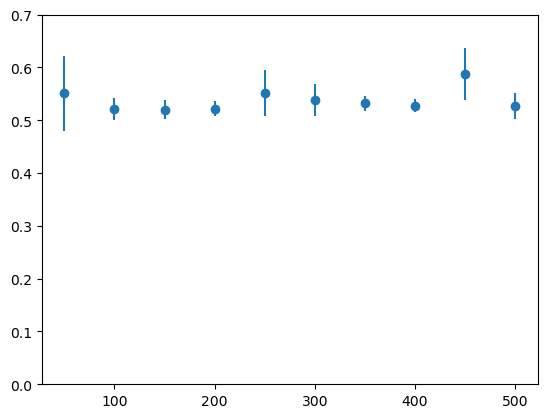

In [46]:
Ns = np.linspace(50, 500, num=10)
nt50 = np.asarray(t50)
nt100 = np.asarray(t100)
nt150 = np.asarray(t150)
nt200 = np.asarray(t200)
nt250 = np.asarray(t250)
nt300 = np.asarray(t300)
nt350 = np.asarray(t350)
nt400 = np.asarray(t400)
nt450 = np.asarray(t450)
nt500 = np.asarray(t500)
nts = np.array([nt50, nt100, nt150, nt200, nt250, nt300, nt350, nt400, nt450, nt500])
means = []
stds = []
for arr in nts:
    means.append(np.mean(arr))
    stds.append(np.std(arr))
print(means)
print(stds)
plt.errorbar(Ns, means, yerr=stds, fmt ='o')
plt.ylim((0, 0.7))
plt.show()

In [ ]:
args = {
    'N' : 500, 
    'x0' : np.array([0.1, 0.1, 0., 0.]),
    'xf' : np.array([0.9, 0.9, 0., 0.]),
    'erg_ub' : 0.01,
    # 'alpha' : 0.8,
}

x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
start = time.time()
lerp_sol = get_sol_from_init(x, args, step_size=1e-3, c=1.0)
end = time.time()
print(end-start)
print_erg(lerp_sol[1]['x'], lerp_sol[1]['u'], lerp_sol[1]['tf'], args, step_size=1e-3, c=1.55)

done in  4546  iterations
7.742043972015381
erg: 0.010005015879869461
unsuccessful, tol:  1.0


In [ ]:
with open('data/50.pkl', 'rb') as f:
    sol50 = pickle.load(f)

with open('data/100.pkl', 'rb') as f:
    sol100 = pickle.load(f)

with open('data/150.pkl', 'rb') as f:
    sol150 = pickle.load(f)

with open('data/200.pkl', 'rb') as f:
    sol200 = pickle.load(f)

with open('data/250.pkl', 'rb') as f:
    sol250 = pickle.load(f)

with open('data/300.pkl', 'rb') as f:
    sol300 = pickle.load(f)

with open('data/350.pkl', 'rb') as f:
    sol350 = pickle.load(f)

with open('data/400.pkl', 'rb') as f:
    sol400 = pickle.load(f)

with open('data/450.pkl', 'rb') as f:
    sol450 = pickle.load(f)

with open('data/500.pkl', 'rb') as f:
    sol500 = pickle.load(f)

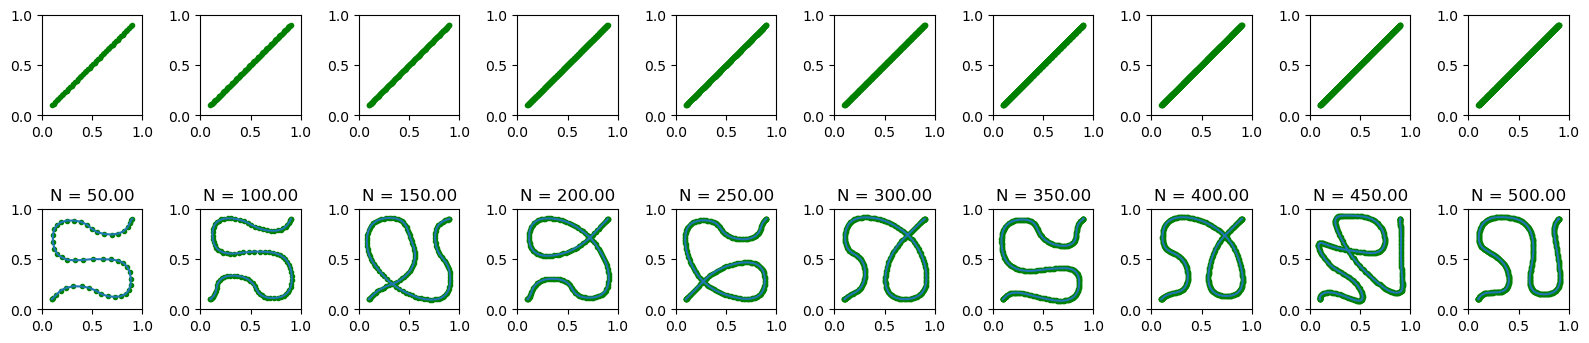

In [ ]:
fig, axs = plt.subplots(2, 10, figsize=(16,4))

plot_traj(axs[:,0], sol50)

plot_traj(axs[:,1], sol100)

plot_traj(axs[:,2], sol150)

plot_traj(axs[:,3], sol200)

plot_traj(axs[:,4], sol250)

plot_traj(axs[:,5], sol300)

plot_traj(axs[:,6], sol350)

plot_traj(axs[:,7], sol400)

plot_traj(axs[:,8], sol450)

plot_traj(axs[:,9], sol500)


fig.tight_layout()